In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib as mpl
from OpenMiChroM.CndbTools import cndbTools as ctools
import yaml
import os
import sys
import shutil
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting, convert
from OpenMiChroM.CndbTools import cndbTools as ctools
from matplotlib.lines import Line2D
import seaborn as sns
import hicstraw
import pandas
from chroma import energy
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


plt.style.use("chroma.tex")

In [2]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [3]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [4]:
plt.rcParams["figure.dpi"] = 1000

# initial tests

In [10]:
traj = ctools()
traj.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/complete/1/nucleus_0.cndb")

Cndb file has 10000 frames, with 4980 beads and {b'B2', b'NA', b'B1', b'A1', b'B3', b'A2'} types 

In [14]:
def spherical_coordinates(xyz):
    if xyz.ndim == 2:
        xyz = xyz[None, :, :]

    r = np.sqrt(np.sum(xyz**2, axis=2))
    theta = np.arccos(xyz[:, :, 2] / r)
    phi = np.arctan2(xyz[:, :, 1], xyz[:, :, 0])
    return r, theta, phi

In [72]:
xyz = traj.xyz(range(10000))

In [73]:
r, theta, phi = spherical_coordinates(xyz)

In [74]:
# Flatten
r_flat = r.reshape(-1)
theta_flat = theta.reshape(-1)   # theta in [0, pi]

# Center theta only for symmetric display
# theta_centered = theta_flat - np.pi / 2

# Mirror across the middle axis
theta_sym = np.hstack((theta_flat, -theta_flat))
r_sym = np.hstack((r_flat, r_flat))

In [63]:
# Histogram with theta on x-axis and r on y-axis
bins_theta = 80
bins_r = 80
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)

theta_lim = np.max(np.abs(theta_flat))

H, theta_edges, r_edges = np.histogram2d(
    theta_sym,
    r_sym,
    bins=[bins_theta, bins_r],
    range=[[-theta_lim, theta_lim], [NUCLEOLI_RADIUS, NUCLEUS_RADIUS]]
)

# Bin centers
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

# Convert centered theta back to physical theta for the Jacobian
theta_phys_centers = theta_centers + np.pi / 2

# Spherical volume correction: 2π r^2 sin(theta)
correction = 2 * np.pi * (r_centers[None, :] ** 2) * np.sin(theta_phys_centers)[:, None]
correction = np.where(np.abs(correction) < 1e-12, 1e-12, correction)

H = H / correction

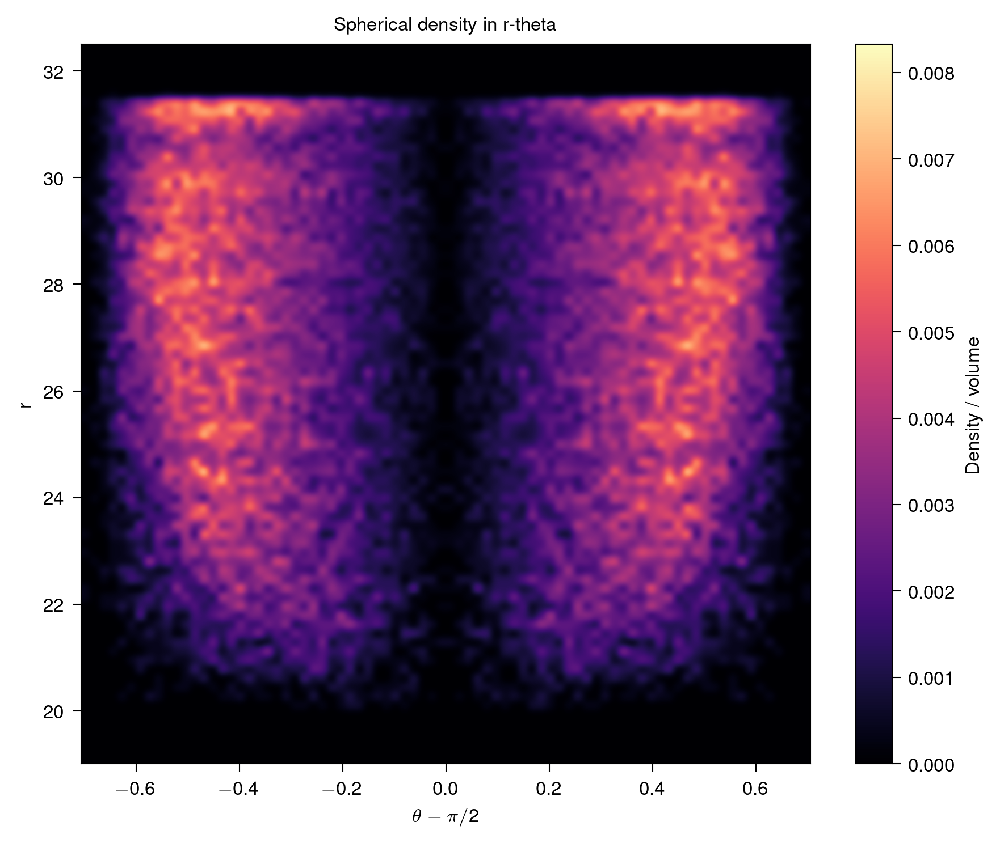

In [64]:
# Plot
plt.figure(figsize=(6, 5))
plt.imshow(
    H.T,
    extent=[-theta_lim, theta_lim, NUCLEOLI_RADIUS, NUCLEUS_RADIUS],
    origin="lower",
    cmap="magma",
    aspect="auto",
    interpolation="gaussian"
)

plt.colorbar(label="Density / volume")
plt.xlabel(r"$\theta - \pi/2$")
plt.ylabel("r")
plt.title("Spherical density in r-theta")
plt.tight_layout()
plt.show()

In [65]:
# Histogram with theta on x-axis and r on y-axis
bins_theta = 80
bins_r = 80
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)

theta_lim = np.max(np.abs(theta_flat))

H, theta_edges, r_edges = np.histogram2d(
    theta_flat,
    r_flat,
    bins=[bins_theta, bins_r],
    range=[[0, theta_lim], [NUCLEOLI_RADIUS, NUCLEUS_RADIUS]]
)

# # Bin centers
# theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
# r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

# # Convert centered theta back to physical theta for the Jacobian
# theta_phys_centers = theta_centers + np.pi / 2

# # Spherical volume correction: 2π r^2 sin(theta)
# correction = 2 * np.pi * (r_centers[None, :] ** 2) * np.sin(theta_phys_centers)[:, None]
# correction = np.where(np.abs(correction) < 1e-12, 1e-12, correction)

# H = H / correction

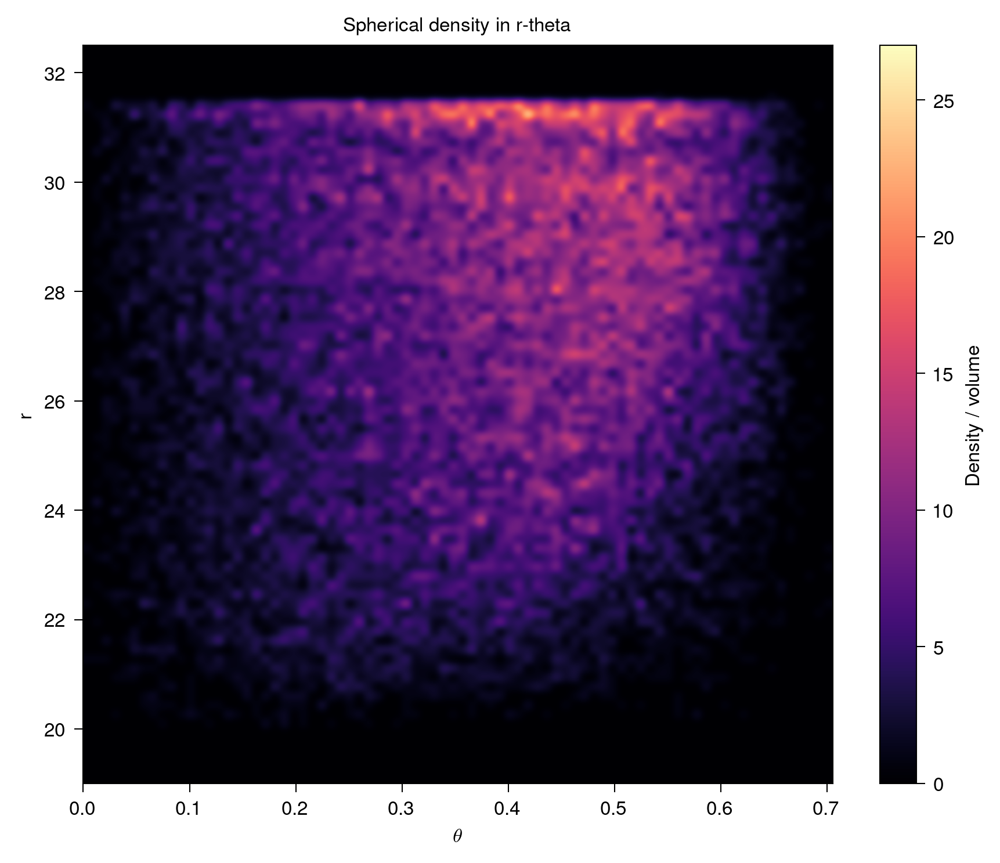

In [66]:
# Plot
plt.figure(figsize=(6, 5))
plt.imshow(
    H.T,
    extent=[0, theta_lim, NUCLEOLI_RADIUS, NUCLEUS_RADIUS],
    origin="lower",
    cmap="magma",
    aspect="auto",
    interpolation="gaussian"
)

plt.colorbar(label="Density / volume")
plt.xlabel(r"$\theta$")
plt.ylabel("r")
plt.title("Spherical density in r-theta")
plt.tight_layout()
plt.show()

In [75]:
recovered_x = r_flat * np.cos(theta_flat)
recovered_y = r_flat * np.sin(theta_flat)

bins_x = np.linspace(np.min(recovered_x), np.max(recovered_x), 100)
bins_y = np.linspace(np.min(recovered_y), np.max(recovered_y), 100)

In [ ]:
theta_lim = np.max(np.abs(theta_flat))

H, x_edges, y_edges = np.histogram2d(
    recovered_x,
    recovered_y,
    bins=[bins_x, bins_y]
)

# # Bin centers
# theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
# r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

# # Convert centered theta back to physical theta for the Jacobian
# theta_phys_centers = theta_centers + np.pi / 2

# # Spherical volume correction: 2π r^2 sin(theta)
# correction = 2 * np.pi * (r_centers[None, :] ** 2) * np.sin(theta_phys_centers)[:, None]
# correction = np.where(np.abs(correction) < 1e-12, 1e-12, correction)

# H = H / correction

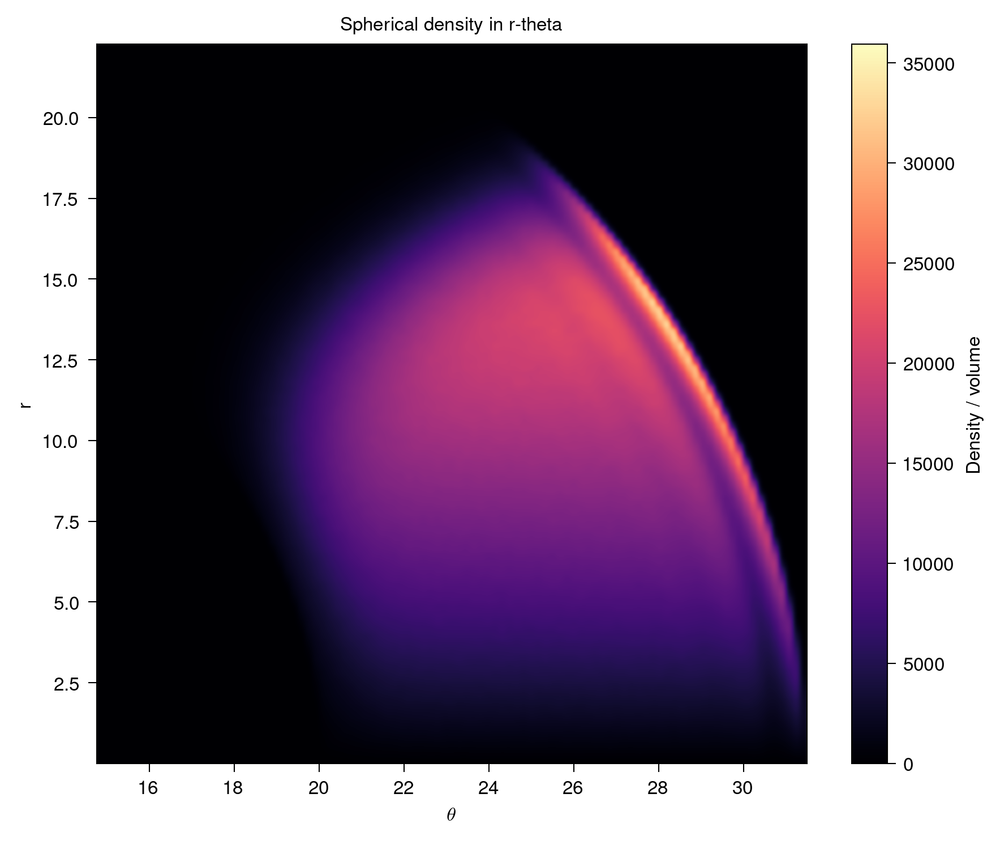

In [77]:
# Plot
plt.figure(figsize=(6, 5))
plt.imshow(
    H.T,
    extent=[np.min(x_edges), np.max(x_edges), np.min(y_edges), np.max(y_edges)],
    origin="lower",
    cmap="magma",
    aspect="auto",
    interpolation="gaussian"
)

plt.colorbar(label="Density / volume")
plt.xlabel(r"$\theta$")
plt.ylabel("r")
plt.title("Spherical density in r-theta")
plt.tight_layout()
plt.show()

In [80]:
bins_x = np.linspace(np.min(xyz[:, :, 0]), np.max(xyz[:, :, 0]), 100)
bins_y = np.linspace(np.min(xyz[:, :, 2]), np.max(xyz[:, :, 2]), 100)

H, x_edges, y_edges = np.histogram2d(
    xyz[:, :, 0].flatten(),
    xyz[:, :, 2].flatten(),
    bins=[bins_x, bins_y]
)

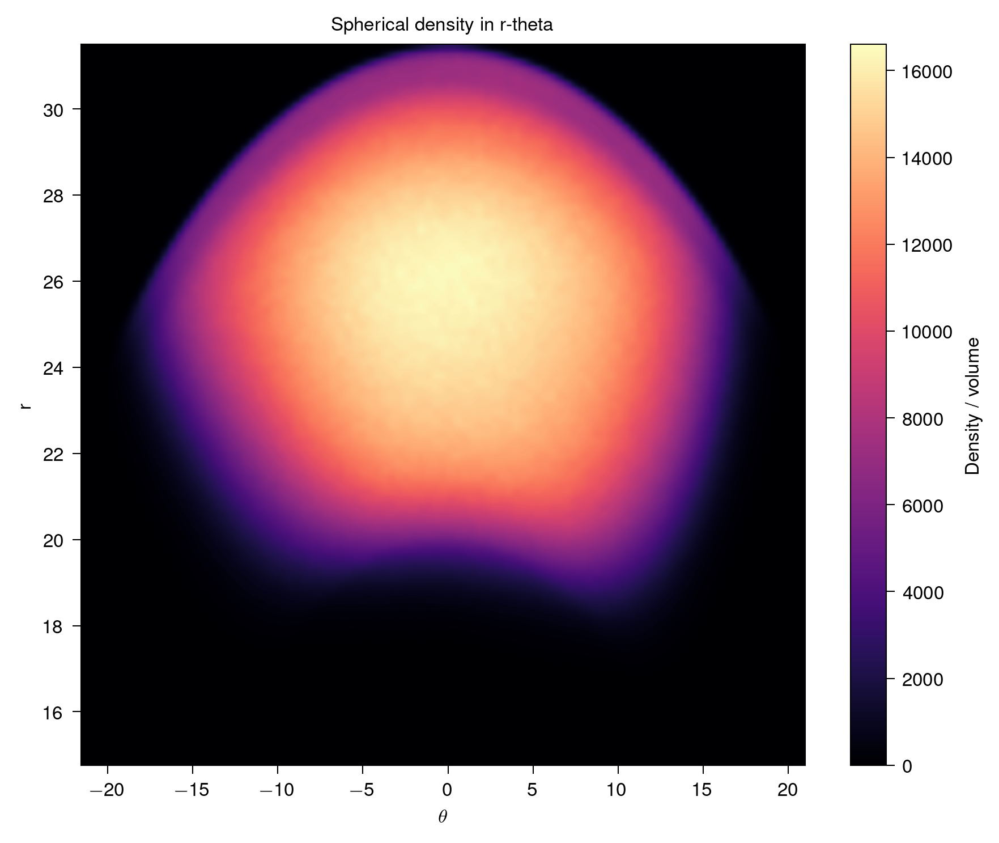

In [81]:
# Plot
plt.figure(figsize=(6, 5))
plt.imshow(
    H.T,
    extent=[np.min(x_edges), np.max(x_edges), np.min(y_edges), np.max(y_edges)],
    origin="lower",
    cmap="magma",
    aspect="auto",
    interpolation="gaussian"
)

plt.colorbar(label="Density / volume")
plt.xlabel(r"$\theta$")
plt.ylabel("r")
plt.title("Spherical density in r-theta")
plt.tight_layout()
plt.show()

(0.0, 32.5)

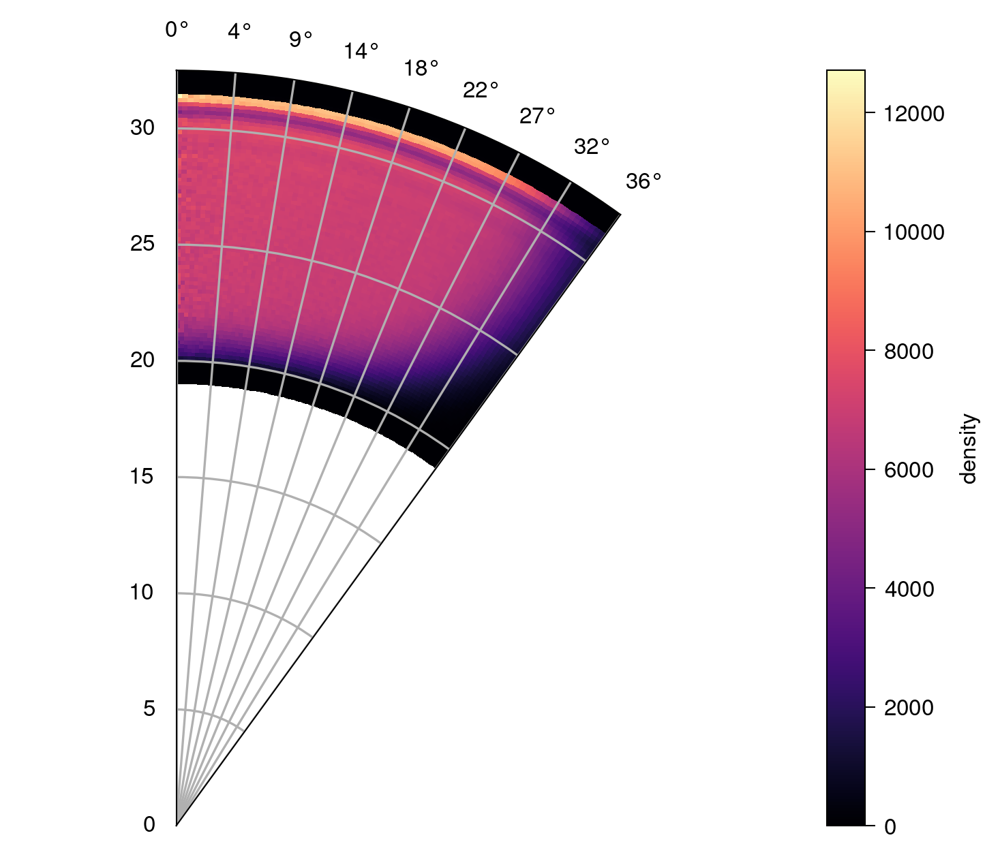

In [88]:
theta = theta_flat
r = r_flat

theta_bins = np.linspace(0, np.pi / 5, 80)   # positive-z cone
r_bins = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 80)

H, theta_edges, r_edges = np.histogram2d(theta, r, bins=[theta_bins, r_bins])

# Normalize by the exact spherical-shell volume of each bin.
shell_volume = (
    (2 * np.pi / 3)
    * (r_edges[None, 1:] ** 3 - r_edges[None, :-1] ** 3)
    * (np.cos(theta_edges[:-1])[:, None] - np.cos(theta_edges[1:])[:, None])
)
shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
H = H / shell_volume

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H.T, shading="auto", cmap="magma")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 5)
ax.set_rlim(0, NUCLEUS_RADIUS)

In [91]:
r_all, theta_all, _ = spherical_coordinates(xyz)

In [ ]:
chr_sequence = np.array([x.decode('utf-8')[0] for x in traj.ChromSeq])

In [93]:
chr_sequence

array(['B', 'B', 'B', ..., 'A', 'A', 'A'], dtype='<U1')

(0.0, 32.5)

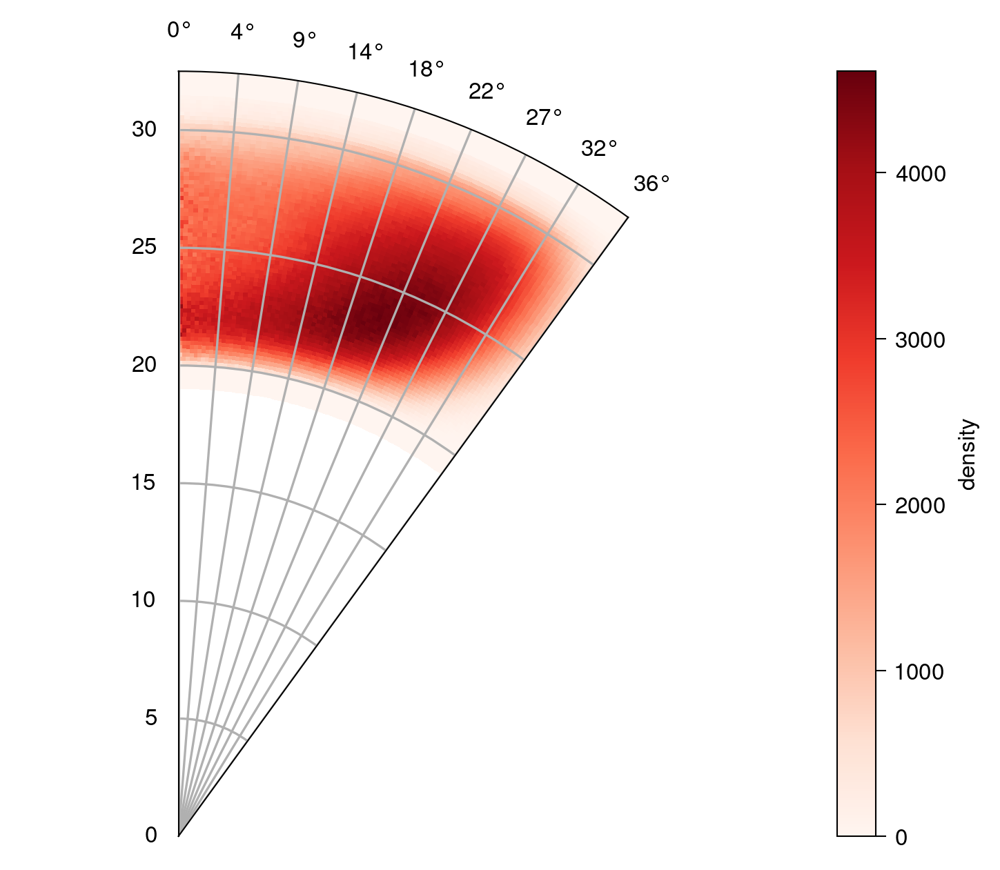

In [94]:
theta = theta_all[:, chr_sequence == "A"].reshape(-1)
r = r_all[:, chr_sequence == "A"].reshape(-1)

theta_bins = np.linspace(0, np.pi / 5, 80)   # positive-z cone
r_bins = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 80)

H, theta_edges, r_edges = np.histogram2d(theta, r, bins=[theta_bins, r_bins])

# Normalize by the exact spherical-shell volume of each bin.
shell_volume = (
    (2 * np.pi / 3)
    * (r_edges[None, 1:] ** 3 - r_edges[None, :-1] ** 3)
    * (np.cos(theta_edges[:-1])[:, None] - np.cos(theta_edges[1:])[:, None])
)
shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
H = H / shell_volume

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H.T, shading="auto", cmap="Reds")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 5)
ax.set_rlim(0, NUCLEUS_RADIUS)

(0.0, 32.5)

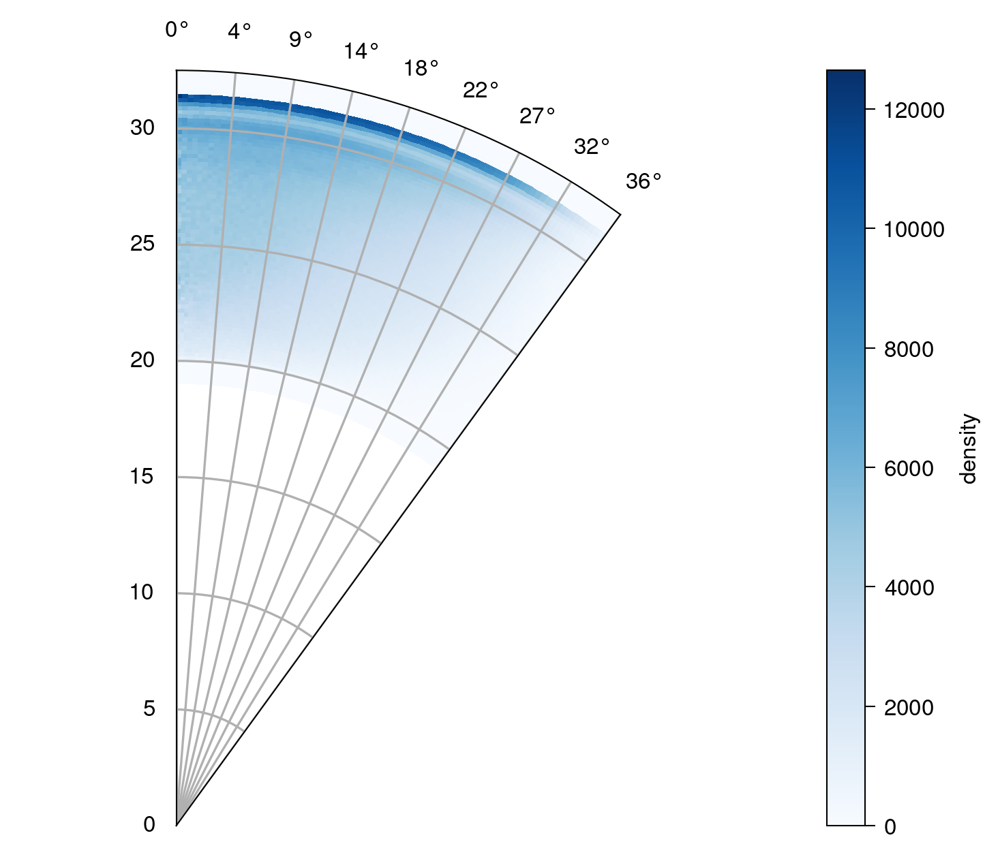

In [95]:
theta = theta_all[:, chr_sequence == "B"].reshape(-1)
r = r_all[:, chr_sequence == "B"].reshape(-1)

theta_bins = np.linspace(0, np.pi / 5, 80)   # positive-z cone
r_bins = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 80)

H, theta_edges, r_edges = np.histogram2d(theta, r, bins=[theta_bins, r_bins])

# Normalize by the exact spherical-shell volume of each bin.
shell_volume = (
    (2 * np.pi / 3)
    * (r_edges[None, 1:] ** 3 - r_edges[None, :-1] ** 3)
    * (np.cos(theta_edges[:-1])[:, None] - np.cos(theta_edges[1:])[:, None])
)
shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
H = H / shell_volume

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H.T, shading="auto", cmap="Blues")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 5)
ax.set_rlim(0, NUCLEUS_RADIUS)

In [102]:
traj = ctools()
traj.load("/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/6_sampling/nucleolus/1/nucleus_0.cndb")
xyz = traj.xyz(range(10000))

In [103]:
r_all, theta_all, _ = spherical_coordinates(xyz)

In [104]:
chr_sequence = np.array([x.decode('utf-8')[0] for x in traj.ChromSeq])

In [105]:
chr_sequence

array(['B', 'B', 'B', ..., 'A', 'A', 'A'], dtype='<U1')

(0.0, 32.5)

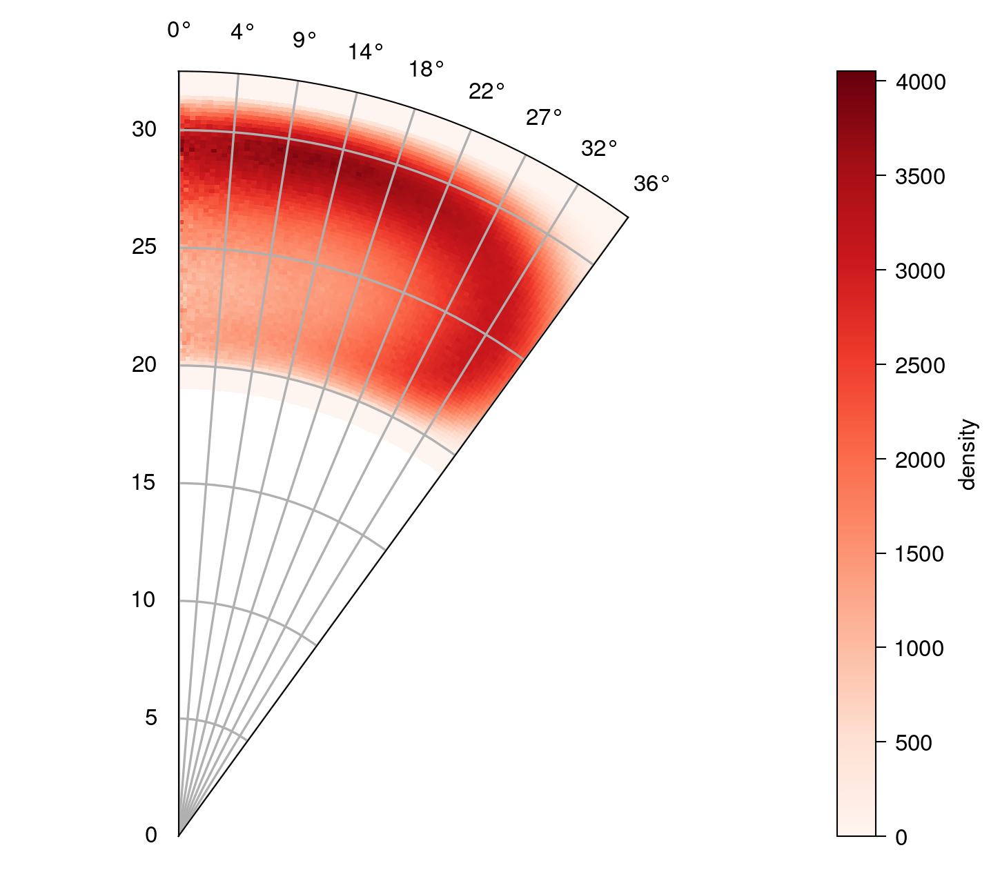

In [106]:
theta = theta_all[:, chr_sequence == "A"].reshape(-1)
r = r_all[:, chr_sequence == "A"].reshape(-1)

theta_bins = np.linspace(0, np.pi / 5, 80)   # positive-z cone
r_bins = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 80)

H, theta_edges, r_edges = np.histogram2d(theta, r, bins=[theta_bins, r_bins])

# Normalize by the exact spherical-shell volume of each bin.
shell_volume = (
    (2 * np.pi / 3)
    * (r_edges[None, 1:] ** 3 - r_edges[None, :-1] ** 3)
    * (np.cos(theta_edges[:-1])[:, None] - np.cos(theta_edges[1:])[:, None])
)
shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
H = H / shell_volume

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H.T, shading="auto", cmap="Reds")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 5)
ax.set_rlim(0, NUCLEUS_RADIUS)

(0.0, 32.5)

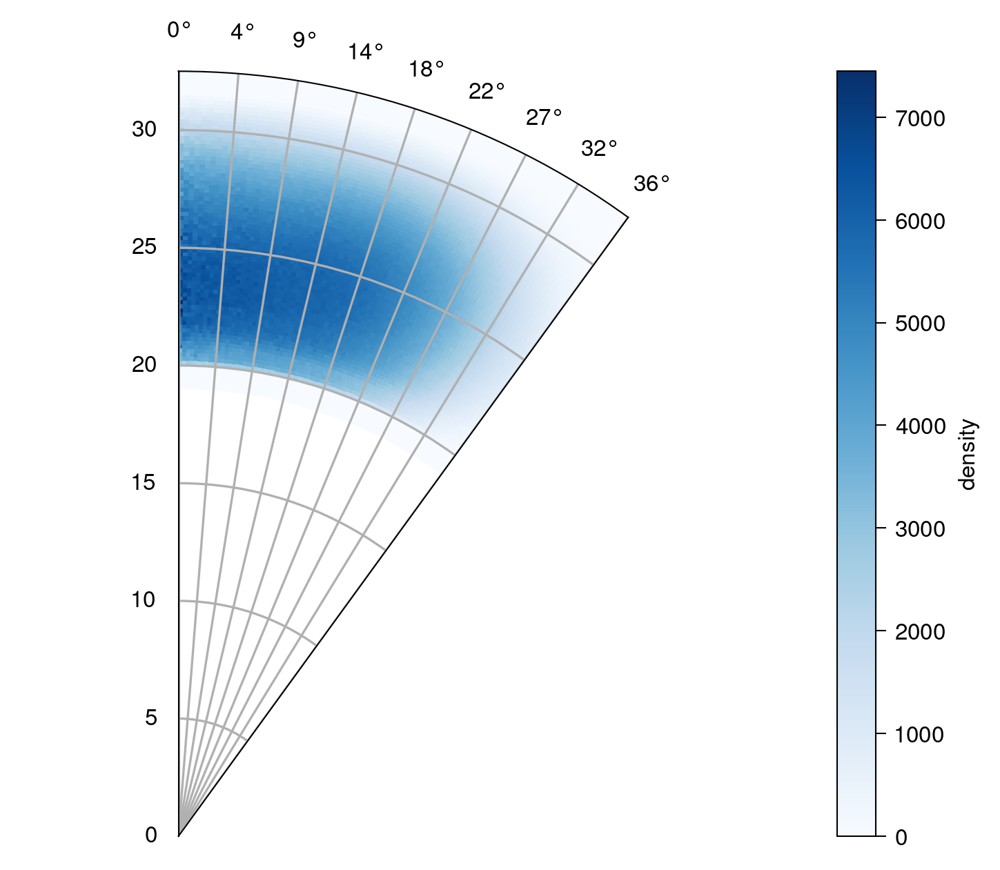

In [109]:
theta = theta_all[:, chr_sequence == "B"].reshape(-1)
r = r_all[:, chr_sequence == "B"].reshape(-1)

theta_bins = np.linspace(0, np.pi / 5, 80)   # positive-z cone
r_bins = np.linspace(NUCLEOLI_RADIUS, NUCLEUS_RADIUS, 80)

H, theta_edges, r_edges = np.histogram2d(theta, r, bins=[theta_bins, r_bins])

# Normalize by the exact spherical-shell volume of each bin.
shell_volume = (
    (2 * np.pi / 3)
    * (r_edges[None, 1:] ** 3 - r_edges[None, :-1] ** 3)
    * (np.cos(theta_edges[:-1])[:, None] - np.cos(theta_edges[1:])[:, None])
)
shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
H = H / shell_volume

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H.T, shading="auto", cmap="Blues")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 5)
ax.set_rlim(0, NUCLEUS_RADIUS)

# chr1 - nuclear bodies as beads

In [4]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/7_analysis/localization/data"

In [5]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [6]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

#### Aggregate data


In [81]:
localization = {}

for condition in conditions:
    localization[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing {condition} replica {replica}")
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/localization-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in localization[condition]:
                    localization[condition][key] = f[key][()]
                elif key in localization[condition] and "bins" not in key:
                    localization[condition][key] += f[key][()]

Processing complete replica 1
Processing complete replica 2
Processing complete replica 3
Processing complete replica 4
Processing complete replica 5
Processing complete replica 6
Processing complete replica 7
Processing complete replica 8
Processing complete replica 9
Processing complete replica 10
Processing complete replica 11
Processing complete replica 12
Processing complete replica 13
Processing complete replica 14
Processing complete replica 15
Processing complete replica 16
Processing complete replica 17
Processing complete replica 18
Processing complete replica 19
Processing complete replica 20
Processing complete replica 21
Processing complete replica 22
Processing complete replica 23
Processing complete replica 24
Processing complete replica 25
Processing complete replica 26
Processing complete replica 27
Processing complete replica 28
Processing complete replica 29
Processing complete replica 30
Processing complete replica 31
Processing complete replica 32
Processing comple

In [82]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "localization-data-aggregated-larger-bins.h5"), "w"
    # os.path.join(OUTPUT_FOLDER, "localization-data-aggregated.h5"), "w"
) as f:
    for condition in localization.keys():
        grp = f.create_group(condition)
        for key in localization[condition].keys():
            grp.create_dataset(key, data=localization[condition][key])

#### Plotting contact analyses

In [7]:
with h5py.File(
    # os.path.join(OUTPUT_FOLDER, "localization-data-aggregated.h5"),
    os.path.join(OUTPUT_FOLDER, "localization-data-aggregated-larger-bins.h5"),
    "r",
) as f:
    localization = {
        condition: {
            key: f[condition][key][()] for key in f[condition].keys()
        }
        for condition in f.keys()
    }

In [8]:
colors = {
    "A1": "red",
    "A": "red",
    "A2": "orange",   
    "B": "blue",
    "B1": "blue",
    "B2": "cyan",
    "B3": "green",
    "NA": "gray",
}

cmap = {}
for annotation, color in colors.items():
    base_rgb = np.array(mpl.colors.to_rgb(color)[:3])  # Get RGB from colormap
    alphas = np.linspace(0.0, 1.0, 256)

    rgba = np.column_stack([
        np.tile(base_rgb, (256, 1)),
        alphas
    ])

    cmap[annotation] = ListedColormap(rgba)

def normalize_shell_histogram(H, theta_edges, r_edges):
    """Normalize an (r, theta) histogram by spherical shell volume."""
    shell_volume = (
        (2 * np.pi / 3)
        * (r_edges[1:] ** 3 - r_edges[:-1] ** 3)[:, None]
        * (
            np.cos(theta_edges[:-1])
            - np.cos(theta_edges[1:])
        )[None, :]
    )
    shell_volume = np.where(shell_volume > 0, shell_volume, np.nan)
    return H / shell_volume / np.sum(H)

(0.0, 32.5)

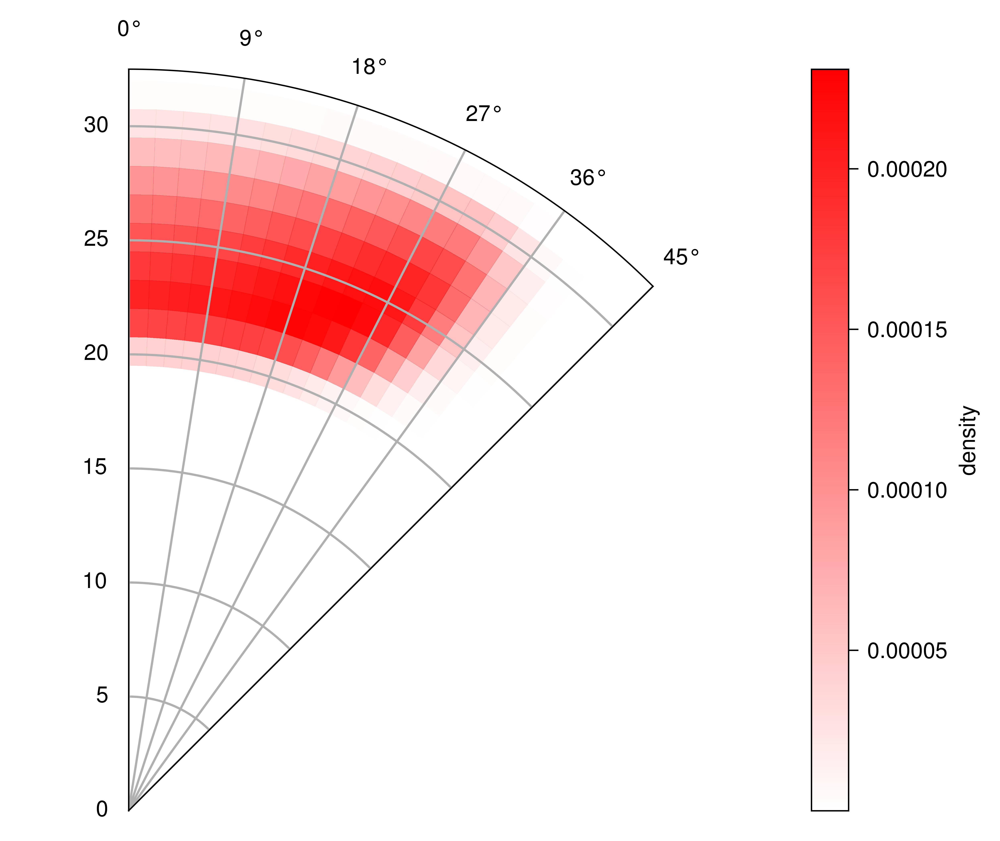

In [85]:
H = localization["complete"]["A1"]
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H = normalize_shell_histogram(H, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H, shading="auto", cmap=cmap["A1"])
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

(0.0, 32.5)

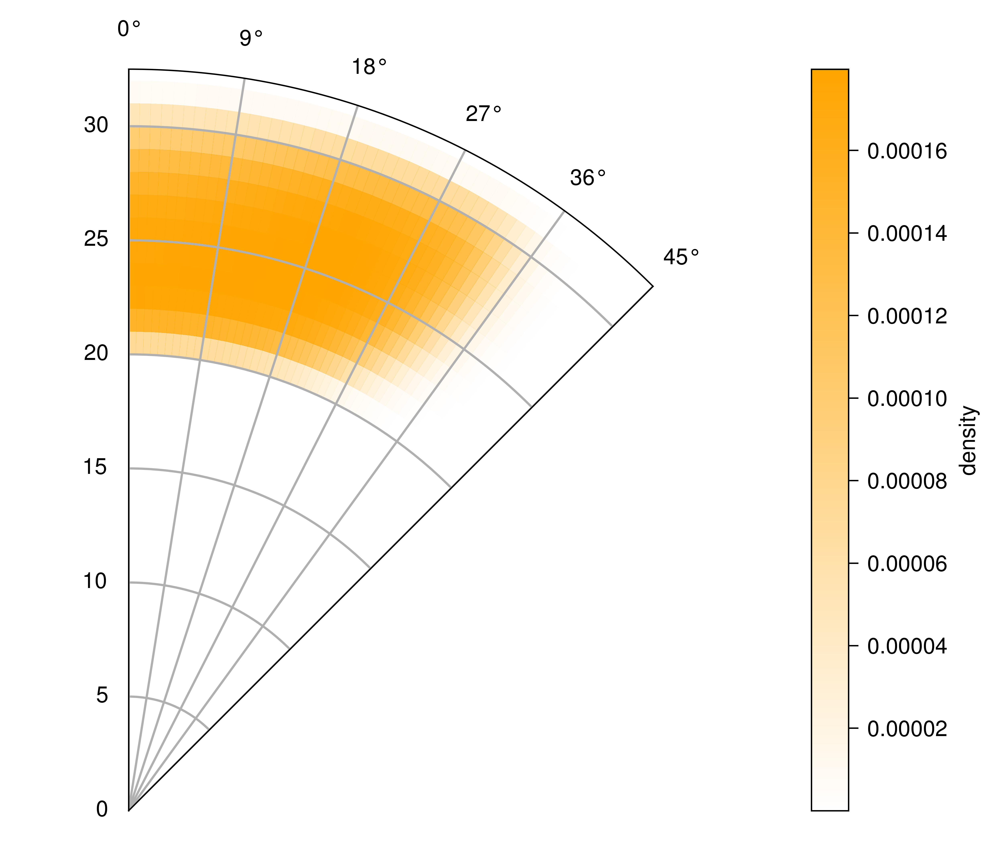

In [71]:
H = localization["complete"]["A2"]
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H = normalize_shell_histogram(H, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H, shading="auto", cmap=cmap["A2"])
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

(0.0, 32.5)

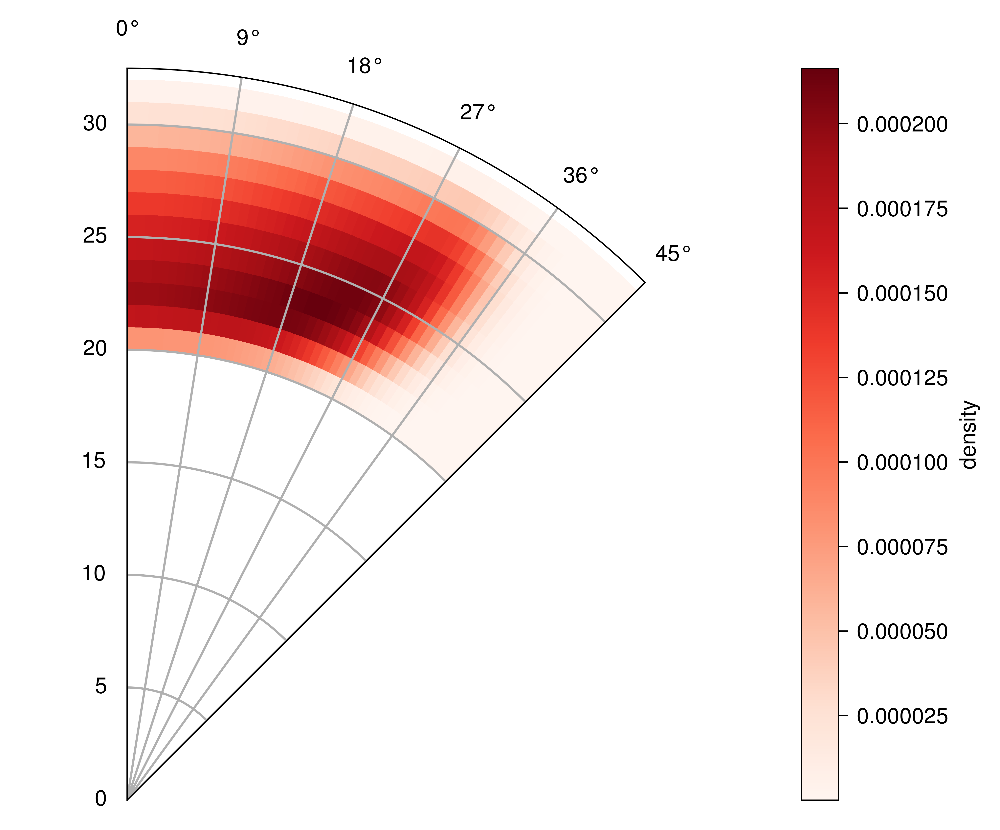

In [72]:
H = localization["complete"]["A2"] + localization["complete"]["A1"]
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H = normalize_shell_histogram(H, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(theta_edges, r_edges, H, shading="auto", cmap="Reds")
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

(0.0, 32.5)

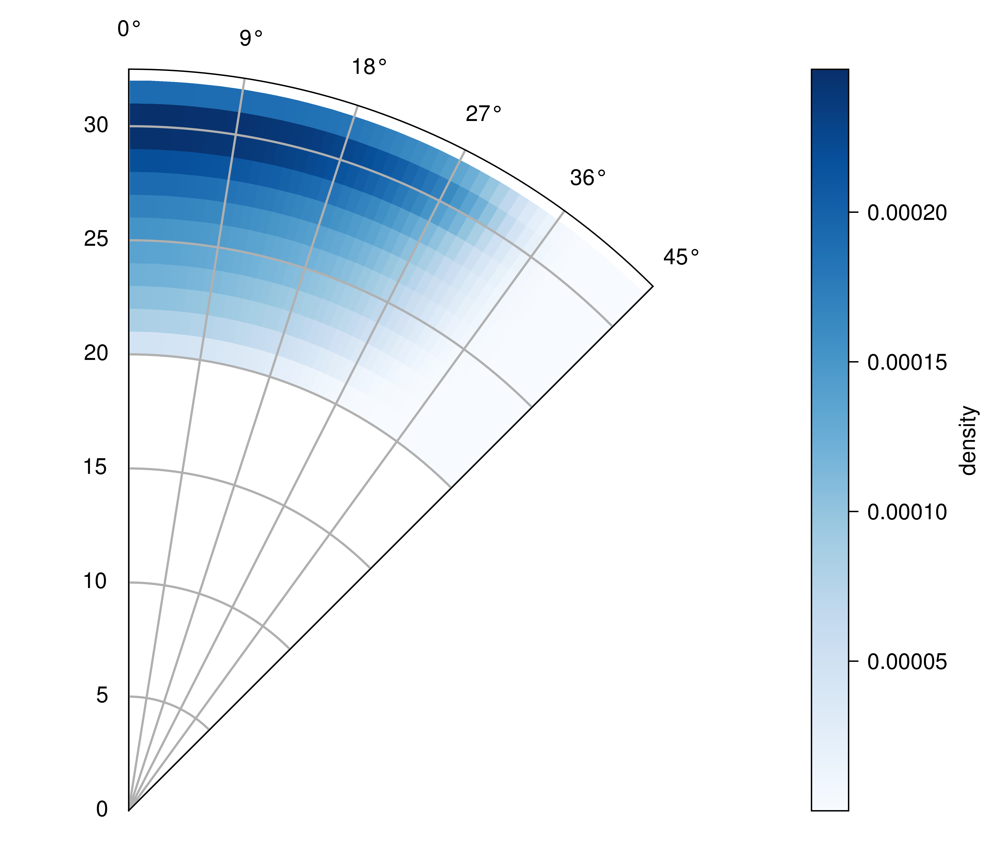

In [73]:
H = (
    localization["complete"]["B1"]
    + localization["complete"]["B2"]
    + localization["complete"]["B3"]
)
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H = normalize_shell_histogram(H, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc = ax.pcolormesh(
    theta_edges, r_edges, H, shading="auto", cmap="Blues"
)
fig.colorbar(pc, ax=ax, label="density")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

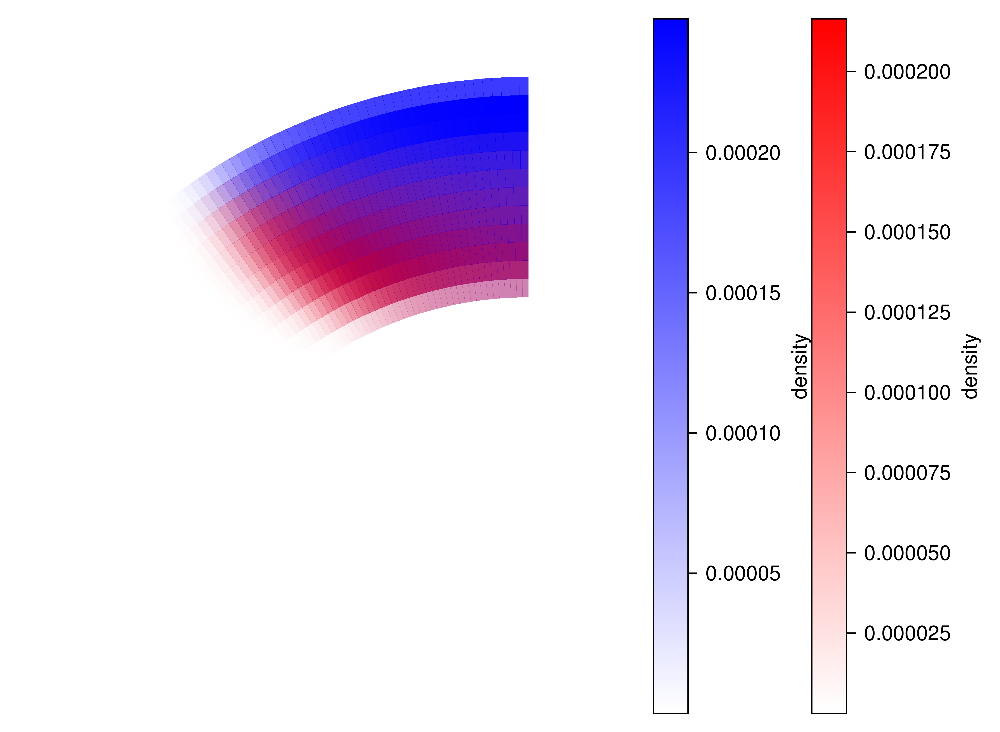

In [74]:
H1 = (
    localization["complete"]["A1"]
    + localization["complete"]["A2"]
)
H2 = (
    localization["complete"]["B1"]
    + localization["complete"]["B2"]
    + localization["complete"]["B3"]
)
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H1 = normalize_shell_histogram(H1, theta_edges, r_edges)
H2 = normalize_shell_histogram(H2, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc1 = ax.pcolormesh(
    theta_edges, r_edges, H1, cmap=cmap["A"]
)
pc2 = ax.pcolormesh(
    theta_edges, r_edges, H2, cmap=cmap["B"]
)
fig.colorbar(pc1, ax=ax, label="density")
fig.colorbar(pc2, ax=ax, label="density")
ax.set_theta_zero_location("N")
# ax.set_theta_direction(-1)
ax.set_thetalim(0, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

fig.savefig(
    "figures/localization-complete.pdf",
    dpi=1000,
)

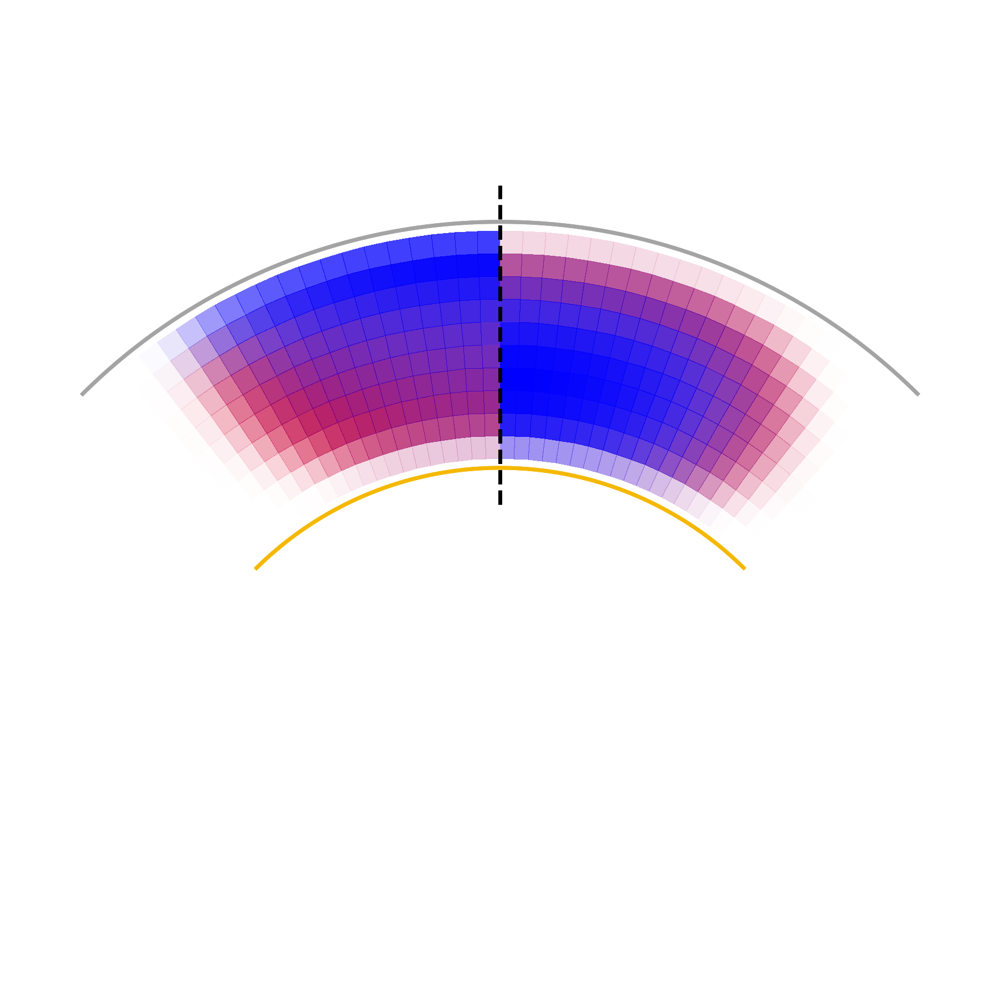

In [20]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(
    1,
    1,
    figsize=(1.6065, 3),
    subplot_kw={"projection": "polar"},
    # layout="constrained",
)

relative_density = {}
for condition in ["complete", "nucleolus"]:
    relative_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    relative_density[condition]["A"] = normalize_shell_histogram(
        H_A, theta_edges, r_edges
    )
    relative_density[condition]["B"] = normalize_shell_histogram(
        H_B, theta_edges, r_edges
    )

vmax = np.nanmax(
    [
        np.nanmax(relative_density["complete"]["A"]),
        np.nanmax(relative_density["nucleolus"]["A"]),
        np.nanmax(relative_density["complete"]["B"]),
        np.nanmax(relative_density["nucleolus"]["B"]),
    ]
)

vmin = np.nanmin(
    [
        np.nanmin(relative_density["complete"]["A"]),
        np.nanmin(relative_density["nucleolus"]["A"]),
        np.nanmin(relative_density["complete"]["B"]),
        np.nanmin(relative_density["nucleolus"]["B"]),
    ]
)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    pc_A = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["A"],
        cmap=cmap["A"],
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )
    pc_B = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["B"],
        cmap=cmap["B"],
        vmin=vmin,
        vmax=vmax,
        shading="auto", 
    )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="#a4a4a4",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

# divider = make_axes_locatable(ax)
# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))


# cbar_right = fig.colorbar(
#     pc_B,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.8,
#     format=formatter,
#     location="bottom",
# )
# cbar_left = fig.colorbar(
#     pc_A,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.8,
#     format=formatter,
#     location="bottom",
# )

# # cbar_left.set_label("Probability density", rotation=90)
# cbar_left.set_ticklabels([])
# cbar_right.set_label("Planar Density Profile")

fig.tight_layout(pad=0)
fig.savefig(
    "figures/localization-relative-density.pdf",
    dpi=1000,
    transparent=True
)

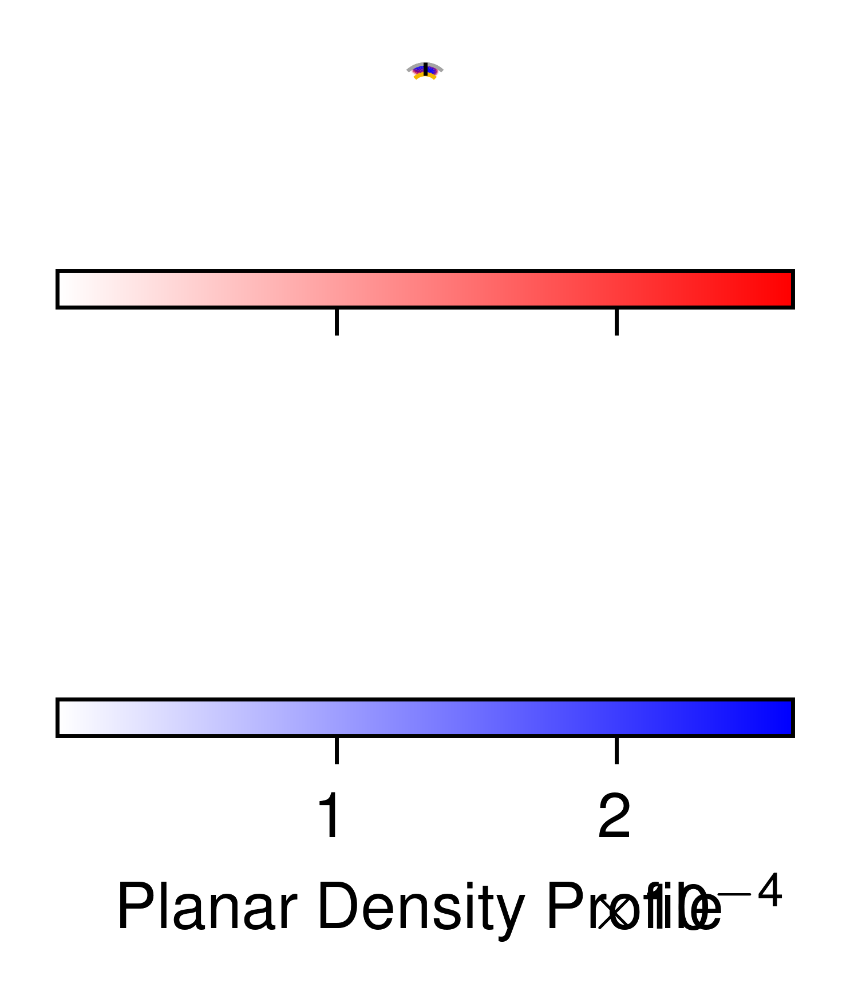

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(
    1,
    1,
    figsize=(1.6065, 3),
    subplot_kw={"projection": "polar"},
    # layout="constrained",
)

relative_density = {}
for condition in ["complete", "nucleolus"]:
    relative_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    relative_density[condition]["A"] = normalize_shell_histogram(
        H_A, theta_edges, r_edges
    )
    relative_density[condition]["B"] = normalize_shell_histogram(
        H_B, theta_edges, r_edges
    )

vmax = np.nanmax(
    [
        np.nanmax(relative_density["complete"]["A"]),
        np.nanmax(relative_density["nucleolus"]["A"]),
        np.nanmax(relative_density["complete"]["B"]),
        np.nanmax(relative_density["nucleolus"]["B"]),
    ]
)

vmin = np.nanmin(
    [
        np.nanmin(relative_density["complete"]["A"]),
        np.nanmin(relative_density["nucleolus"]["A"]),
        np.nanmin(relative_density["complete"]["B"]),
        np.nanmin(relative_density["nucleolus"]["B"]),
    ]
)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    pc_A = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["A"],
        cmap=cmap["A"],
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )
    pc_B = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["B"],
        cmap=cmap["B"],
        vmin=vmin,
        vmax=vmax,
        shading="auto", 
    )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="#a4a4a4",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

divider = make_axes_locatable(ax)
formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))


cbar_right = fig.colorbar(
    pc_B,
    ax=ax,
    orientation="horizontal",
    shrink=0.8,
    format=formatter,
    location="bottom",
)
cbar_left = fig.colorbar(
    pc_A,
    ax=ax,
    orientation="horizontal",
    shrink=0.8,
    format=formatter,
    location="bottom",
)

# cbar_left.set_label("Probability density", rotation=90)
cbar_left.set_ticklabels([])
cbar_right.set_label("Planar Density Profile")

fig.tight_layout(pad=0)
fig.savefig(
    "figures/localization-relative-density-label.pdf",
    dpi=1000,
    transparent=True
)

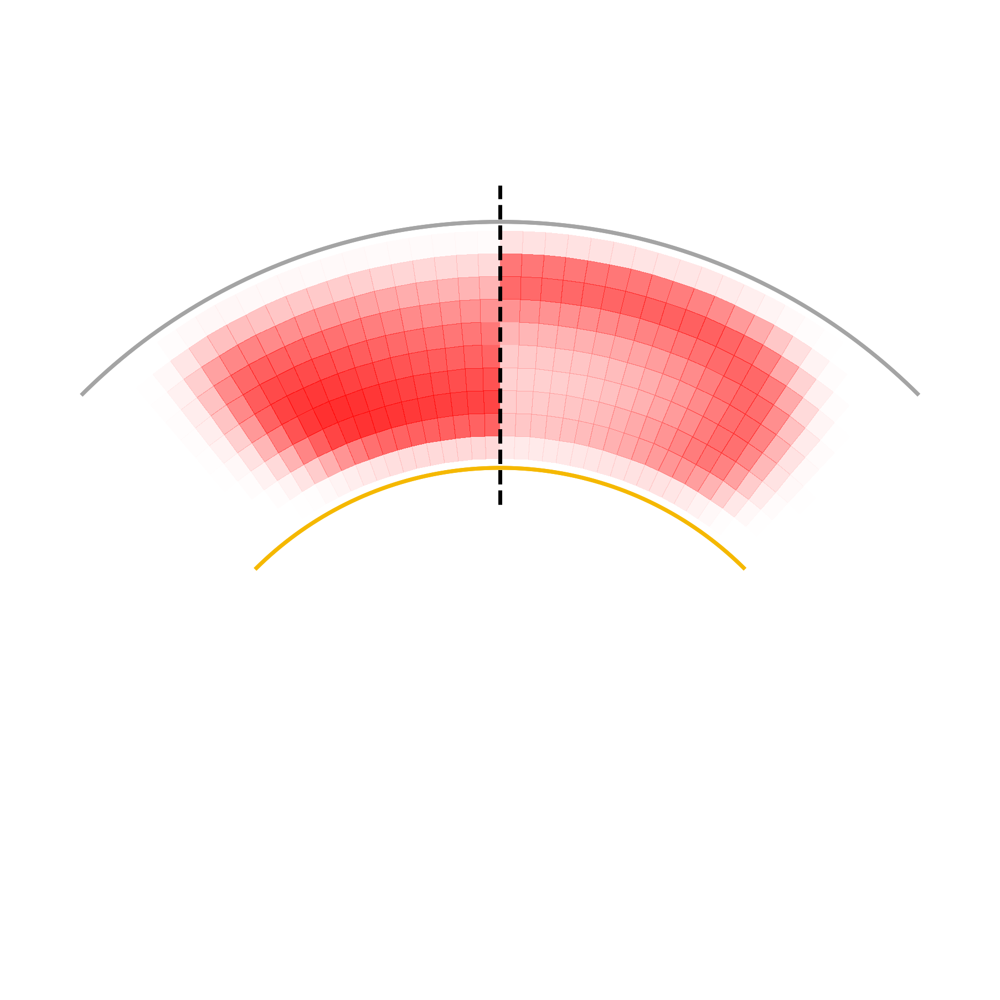

In [22]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(
    1,
    1,
    figsize=(1.6065, 3),
    subplot_kw={"projection": "polar"},
    # layout="constrained",
)

relative_density = {}
for condition in ["complete", "nucleolus"]:
    relative_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    relative_density[condition]["A"] = normalize_shell_histogram(
        H_A, theta_edges, r_edges
    )
    relative_density[condition]["B"] = normalize_shell_histogram(
        H_B, theta_edges, r_edges
    )

vmax = np.nanmax(
    [
        np.nanmax(relative_density["complete"]["A"]),
        np.nanmax(relative_density["nucleolus"]["A"]),
        np.nanmax(relative_density["complete"]["B"]),
        np.nanmax(relative_density["nucleolus"]["B"]),
    ]
)

vmin = np.nanmin(
    [
        np.nanmin(relative_density["complete"]["A"]),
        np.nanmin(relative_density["nucleolus"]["A"]),
        np.nanmin(relative_density["complete"]["B"]),
        np.nanmin(relative_density["nucleolus"]["B"]),
    ]
)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    pc_A = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["A"],
        cmap=cmap["A"],
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )
    # pc_B = ax.pcolormesh(
    #     theta_plot,
    #     r_edges,
    #     relative_density[condition]["B"],
    #     cmap=cmap["B"],
    #     vmin=vmin,
    #     vmax=vmax,
    #     shading="auto", 
    # )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="#a4a4a4",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

# divider = make_axes_locatable(ax)
# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))


# cbar_right = fig.colorbar(
#     pc_B,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.8,
#     format=formatter,
#     location="bottom",
# )
# cbar_left = fig.colorbar(
#     pc_A,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.8,
#     format=formatter,
#     location="bottom",
# )

# # cbar_left.set_label("Probability density", rotation=90)
# cbar_left.set_ticklabels([])
# cbar_right.set_label("Planar Density Profile")

fig.tight_layout(pad=0)
fig.savefig(
    "figures/localization-relative-density-A.pdf",
    dpi=1000,
    transparent=True
)

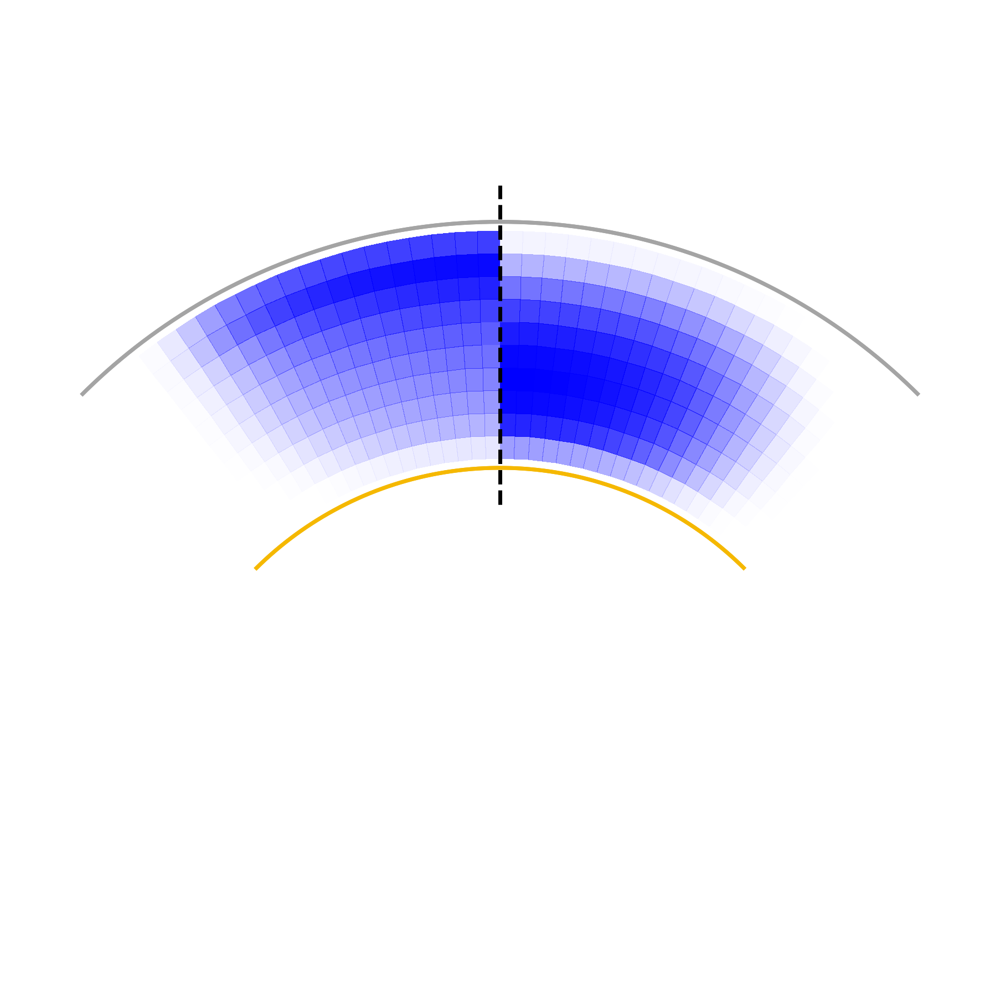

In [23]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(1.6065, 3),
    subplot_kw={"projection": "polar"},
    # layout="constrained",
)

relative_density = {}
for condition in ["complete", "nucleolus"]:
    relative_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    relative_density[condition]["A"] = normalize_shell_histogram(
        H_A, theta_edges, r_edges
    )
    relative_density[condition]["B"] = normalize_shell_histogram(
        H_B, theta_edges, r_edges
    )

vmax = np.nanmax(
    [
        np.nanmax(relative_density["complete"]["A"]),
        np.nanmax(relative_density["nucleolus"]["A"]),
        np.nanmax(relative_density["complete"]["B"]),
        np.nanmax(relative_density["nucleolus"]["B"]),
    ]
)

vmin = np.nanmin(
    [
        np.nanmin(relative_density["complete"]["A"]),
        np.nanmin(relative_density["nucleolus"]["A"]),
        np.nanmin(relative_density["complete"]["B"]),
        np.nanmin(relative_density["nucleolus"]["B"]),
    ]
)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    # pc_A = ax.pcolormesh(
    #     theta_plot,
    #     r_edges,
    #     relative_density[condition]["A"],
    #     cmap=cmap["A"],
    #     vmin=vmin,
    #     vmax=vmax,
    #     shading="auto",
    # )
    pc_B = ax.pcolormesh(
        theta_plot,
        r_edges,
        relative_density[condition]["B"],
        cmap=cmap["B"],
        vmin=vmin,
        vmax=vmax,
        shading="auto", 
    )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="#a4a4a4",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

# divider = make_axes_locatable(ax)
# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))

# cbar_right = fig.colorbar(
#     pc_B,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.3,
#     format=formatter,
#     location="bottom",
# )
# cbar_left = fig.colorbar(
#     pc_A,
#     ax=ax,
#     orientation="horizontal",
#     shrink=0.3,
#     format=formatter,
#     location="bottom",
# )

# # # cbar_left.set_label("Probability density", rotation=90)
# cbar_left.set_ticklabels([])
# cbar_right.set_ticklabels([])
# cbar_right.set_label("Planar Density Profile")

fig.tight_layout(pad=0)
fig.savefig(
    "figures/localization-relative-density-B.pdf",
    dpi=1000,
    transparent=True
)

In [89]:
r_edges

array([19.5061153 , 20.75550377, 22.00489224, 23.25428071, 24.50366918,
       25.75305765, 27.00244612, 28.25183459, 29.50122306, 30.75061153,
       32.        ])

In [80]:
np.linspace(NUCLEOLI_RADIUS+0.5, NUCLEUS_RADIUS-0.5, 11)

array([19.5061153 , 20.75550377, 22.00489224, 23.25428071, 24.50366918,
       25.75305765, 27.00244612, 28.25183459, 29.50122306, 30.75061153,
       32.        ])

In [76]:
NUCLEOLI_RADIUS

19.00611529838363

In [ ]:
19.5 to 32

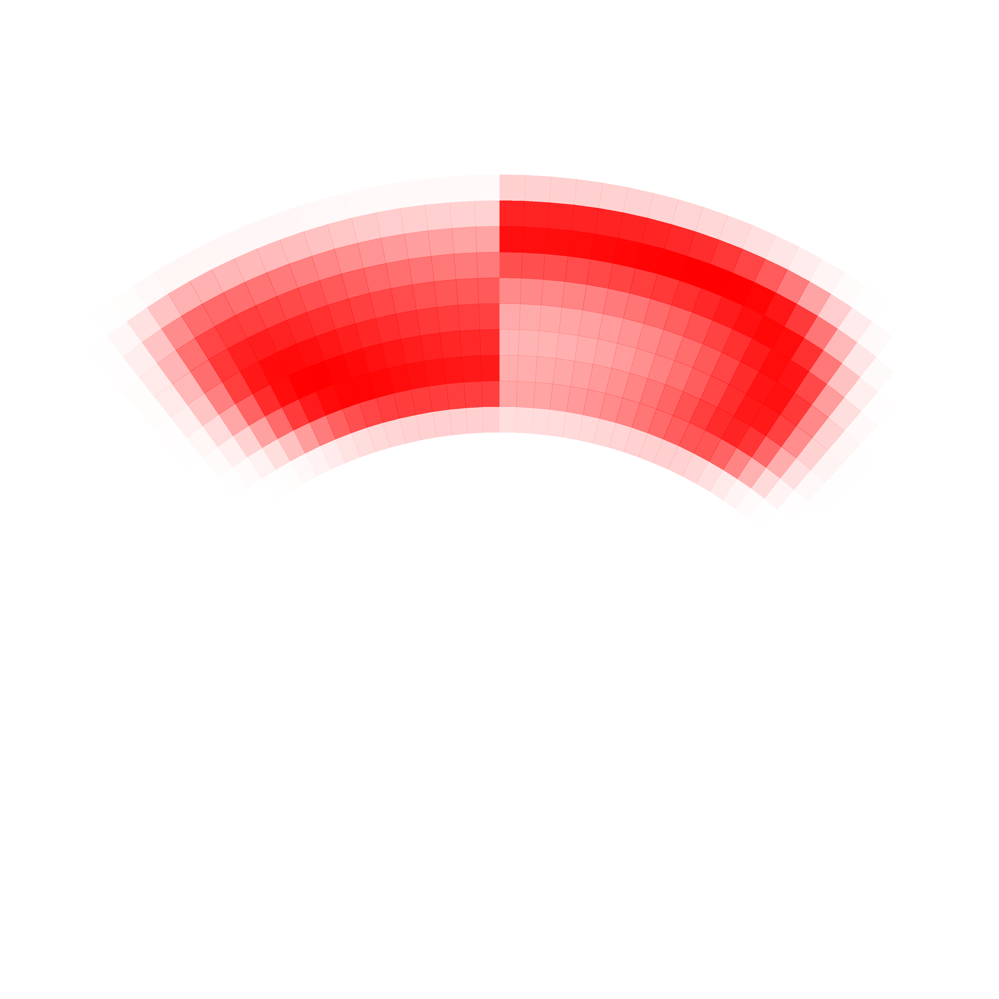

In [87]:
H1 = (
    localization["complete"]["A1"]
    + localization["complete"]["A2"]
)
H2 = (
    localization["complete"]["B1"]
    + localization["complete"]["B2"]
    + localization["complete"]["B3"]
)
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H1 = normalize_shell_histogram(H1, theta_edges, r_edges)
H2 = normalize_shell_histogram(H2, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
pc1 = ax.pcolormesh(
    theta_edges, r_edges, H1, cmap=cmap["A"]
)
# pc2 = ax.pcolormesh(
#     theta_edges, r_edges, H2, cmap=cmap["B"]
# )

H3 = (
    localization["nucleolus"]["A1"]
    + localization["nucleolus"]["A2"]
)
H4 = (
    localization["nucleolus"]["B1"]
    + localization["nucleolus"]["B2"]
    + localization["nucleolus"]["B3"]
)
theta_edges = localization["nucleolus"]["theta_bins"]
r_edges = localization["nucleolus"]["r_bins"]

H3 = normalize_shell_histogram(H3, theta_edges, r_edges)
H4 = normalize_shell_histogram(H4, theta_edges, r_edges)

pc3 = ax.pcolormesh(
    -theta_edges, r_edges, H3, cmap=cmap["A"]
)
# pc4 = ax.pcolormesh(
#     -theta_edges, r_edges, H4, cmap=cmap["B"]
# )
# fig.colorbar(pc3, ax=ax, label="density")
# fig.colorbar(pc4, ax=ax, label="density")
ax.set_theta_zero_location("N")
# ax.set_theta_direction(-1)
ax.set_thetalim(-np.pi / 4, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

fig.savefig(
    "figures/localization-A.pdf",
    dpi=1000,
)

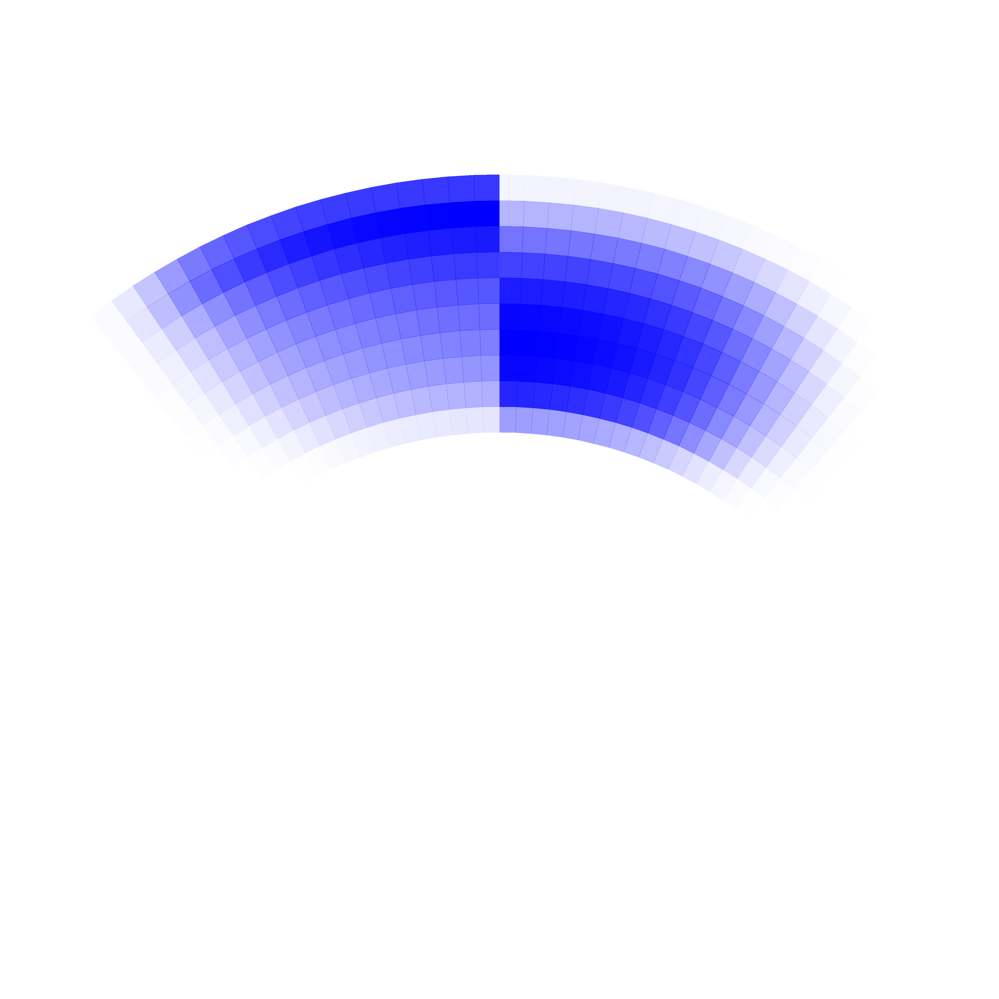

In [88]:
H1 = (
    localization["complete"]["A1"]
    + localization["complete"]["A2"]
)
H2 = (
    localization["complete"]["B1"]
    + localization["complete"]["B2"]
    + localization["complete"]["B3"]
)
theta_edges = localization["complete"]["theta_bins"]
r_edges = localization["complete"]["r_bins"]

H1 = normalize_shell_histogram(H1, theta_edges, r_edges)
H2 = normalize_shell_histogram(H2, theta_edges, r_edges)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
# pc1 = ax.pcolormesh(
#     theta_edges, r_edges, H1, cmap=cmap["A"]
# )
pc2 = ax.pcolormesh(
    theta_edges, r_edges, H2, cmap=cmap["B"]
)

H3 = (
    localization["nucleolus"]["A1"]
    + localization["nucleolus"]["A2"]
)
H4 = (
    localization["nucleolus"]["B1"]
    + localization["nucleolus"]["B2"]
    + localization["nucleolus"]["B3"]
)
theta_edges = localization["nucleolus"]["theta_bins"]
r_edges = localization["nucleolus"]["r_bins"]

H3 = normalize_shell_histogram(H3, theta_edges, r_edges)
H4 = normalize_shell_histogram(H4, theta_edges, r_edges)

# pc3 = ax.pcolormesh(
#     -theta_edges, r_edges, H3, cmap=cmap["A"]
# )
pc4 = ax.pcolormesh(
    -theta_edges, r_edges, H4, cmap=cmap["B"]
)
# fig.colorbar(pc3, ax=ax, label="density")
# fig.colorbar(pc4, ax=ax, label="density")
ax.set_theta_zero_location("N")
# ax.set_theta_direction(-1)
ax.set_thetalim(-np.pi / 4, np.pi / 4)
ax.set_rlim(0, NUCLEUS_RADIUS)

ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

fig.savefig(
    "figures/localization-B.pdf",
    dpi=1000,
)

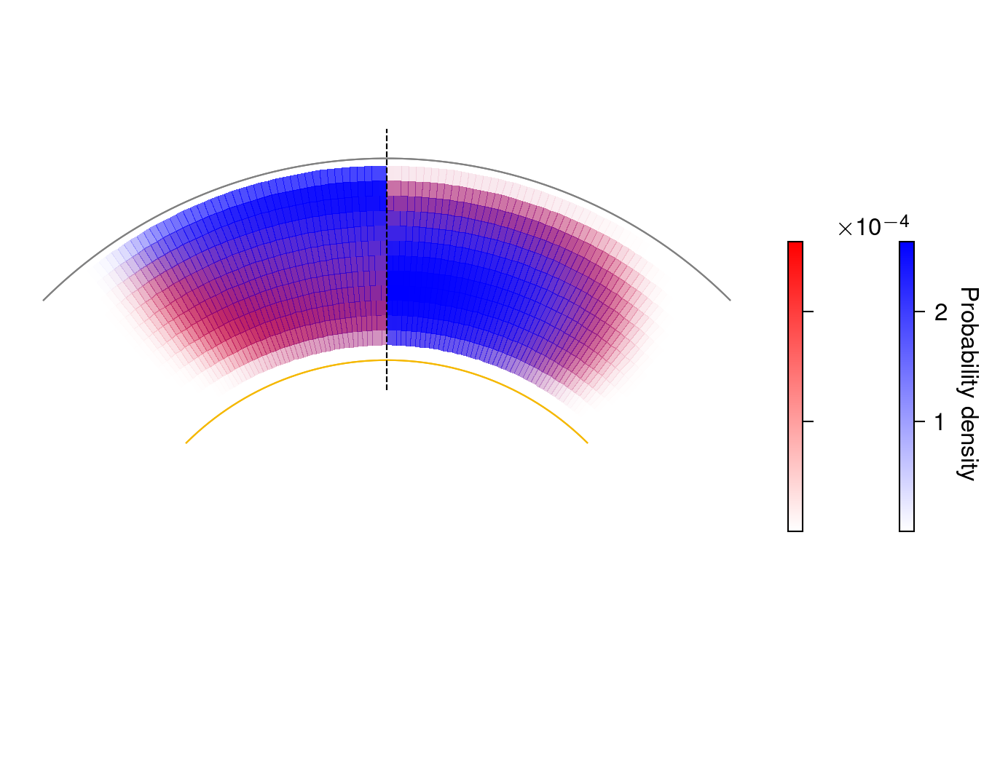

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def probability_shell_density(H, theta_edges, r_edges):
    total = np.sum(H)
    if total <= 0:
        return np.full_like(H, np.nan, dtype=float)
    return normalize_shell_histogram(H / total, theta_edges, r_edges)


fig, ax = plt.subplots(
    1,
    1,
    figsize=(4.5, 4.5),
    subplot_kw={"projection": "polar"},
    layout="constrained",
)

prob_density = {}
for condition in ["complete", "nucleolus"]:
    prob_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    prob_density[condition]["A"] = probability_shell_density(
        H_A, theta_edges, r_edges
    )
    prob_density[condition]["B"] = probability_shell_density(
        H_B, theta_edges, r_edges
    )

vmax_A = np.nanmax(
    [
        np.nanmax(prob_density["complete"]["A"]),
        np.nanmax(prob_density["nucleolus"]["A"]),
    ]
)
vmax_B = np.nanmax(
    [
        np.nanmax(prob_density["complete"]["B"]),
        np.nanmax(prob_density["nucleolus"]["B"]),
    ]
)

vmin_A = np.nanmin(
    [
        np.nanmin(prob_density["complete"]["A"]),
        np.nanmin(prob_density["nucleolus"]["A"]),
    ]
)
vmin_B = np.nanmin(
    [
        np.nanmin(prob_density["complete"]["B"]),
        np.nanmin(prob_density["nucleolus"]["B"]),
    ]
)

vmax_A = max(vmax_A, vmax_B)
vmax_B = max(vmax_A, vmax_B)

vmin_A = min(vmin_A, vmin_B)
vmin_B = min(vmin_A, vmin_B)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    pc_A = ax.pcolormesh(
        theta_plot,
        r_edges,
        prob_density[condition]["A"],
        cmap=cmap["A"],
        vmin=vmin_A,
        vmax=vmax_A,
    )
    pc_B = ax.pcolormesh(
        theta_plot,
        r_edges,
        prob_density[condition]["B"],
        cmap=cmap["B"],
        vmin=vmin_B,
        vmax=vmax_B,
    )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="gray",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

# divider = make_axes_locatable(ax)
formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))


cbar_right = fig.colorbar(
    pc_B,
    ax=ax,
    orientation="vertical",
    shrink=0.3,
    format=formatter,
    # location="right",
)
cbar_left = fig.colorbar(
    pc_A,
    ax=ax,
    orientation="vertical",
    shrink=0.3,
    format=formatter,
    # location="left",
)

# cbar_left.set_label("Probability density", rotation=90)
cbar_left.set_ticklabels([])
cbar_right.set_label("Probability density", rotation=270, labelpad=10)

fig.savefig(
    "figures/localization-probability-density.pdf",
    dpi=1000,
)

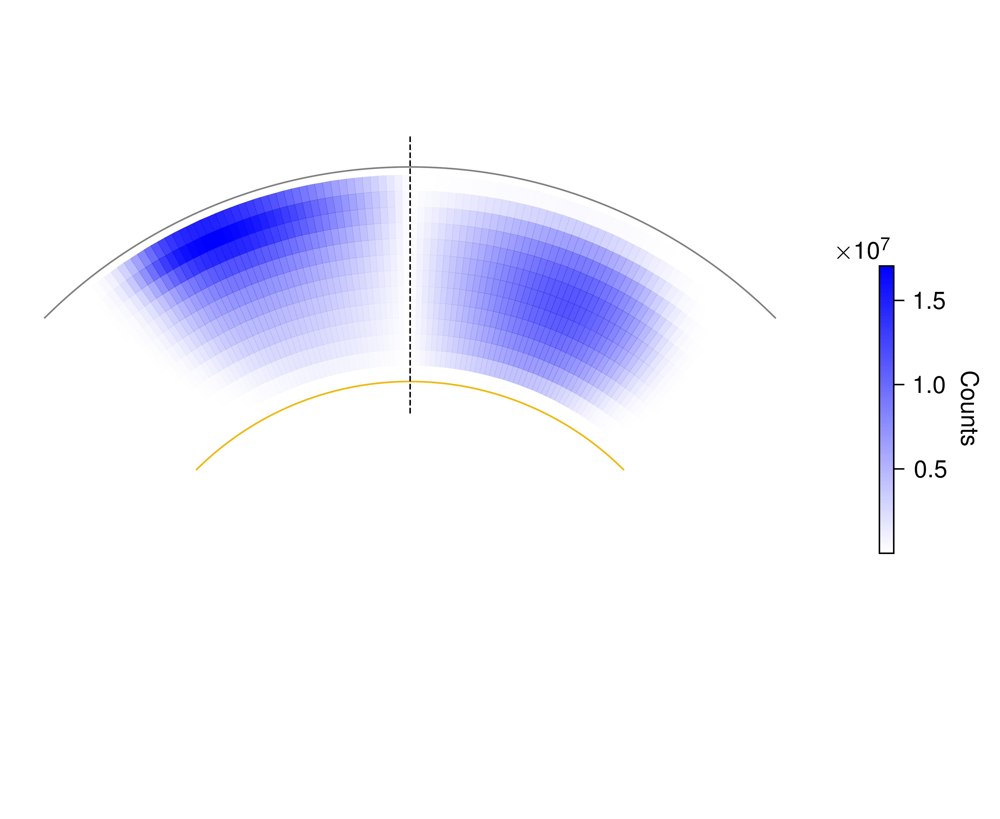

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def probability_shell_density(H, theta_edges, r_edges):
    total = np.sum(H)
    if total <= 0:
        return np.full_like(H, np.nan, dtype=float)
    return normalize_shell_histogram(H / total, theta_edges, r_edges)


fig, ax = plt.subplots(
    1,
    1,
    figsize=(4.5, 4.5),
    subplot_kw={"projection": "polar"},
    layout="constrained",
)

prob_density = {}
for condition in ["complete", "nucleolus"]:
    prob_density[condition] = {}
    H_A = (
        localization[condition]["A1"] + localization[condition]["A2"]
    )
    H_B = (
        localization[condition]["B1"]
        + localization[condition]["B2"]
        + localization[condition]["B3"]
    )
    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    prob_density[condition]["A"] = H_A
    prob_density[condition]["B"] = H_B
    # prob_density[condition]["A"] = probability_shell_density(
    #     H_A, theta_edges, r_edges
    # )
    # prob_density[condition]["B"] = probability_shell_density(
    #     H_B, theta_edges, r_edges
    # )

vmax_A = np.nanmax(
    [
        np.nanmax(prob_density["complete"]["A"]),
        np.nanmax(prob_density["nucleolus"]["A"]),
    ]
)
vmax_B = np.nanmax(
    [
        np.nanmax(prob_density["complete"]["B"]),
        np.nanmax(prob_density["nucleolus"]["B"]),
    ]
)

vmin_A = np.nanmin(
    [
        np.nanmin(prob_density["complete"]["A"]),
        np.nanmin(prob_density["nucleolus"]["A"]),
    ]
)
vmin_B = np.nanmin(
    [
        np.nanmin(prob_density["complete"]["B"]),
        np.nanmin(prob_density["nucleolus"]["B"]),
    ]
)

vmax_A = max(vmax_A, vmax_B)
vmax_B = max(vmax_A, vmax_B)

vmin_A = min(vmin_A, vmin_B)
vmin_B = min(vmin_A, vmin_B)

for condition, theta_sign in [
    ("complete", 1.0),
    ("nucleolus", -1.0),
]:

    theta_edges = localization[condition]["theta_bins"]
    r_edges = localization[condition]["r_bins"]

    theta_plot = theta_sign * theta_edges

    # pc_A = ax.pcolormesh(
    #     theta_plot,
    #     r_edges,
    #     prob_density[condition]["A"],
    #     cmap=cmap["A"],
    #     vmin=vmin_A,
    #     vmax=vmax_A,
    # )
    pc_B = ax.pcolormesh(
        theta_plot,
        r_edges,
        prob_density[condition]["B"],
        cmap=cmap["B"],
        vmin=vmin_B,
        vmax=vmax_B,
    )

    theta = np.linspace(-np.pi / 4, np.pi / 4, 500)
    ax.plot(
        theta,
        np.full_like(theta, NUCLEUS_RADIUS),
        color="gray",
        linewidth=0.5,
    )
    ax.plot(
        theta,
        np.full_like(theta, NUCLEOLI_RADIUS),
        color="#f5b800",
        linewidth=0.5,
    )
    ax.plot(
        np.zeros(500),
        np.linspace(NUCLEOLI_RADIUS - 2, NUCLEUS_RADIUS + 2, 500),
        color="black",
        linestyle="--",
        linewidth=0.5,
    )
    ax.set_theta_zero_location("N")
    ax.set_thetalim(-np.pi / 4, np.pi / 4)
    ax.set_rlim(0, NUCLEUS_RADIUS + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

# divider = make_axes_locatable(ax)
formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))


cbar_right = fig.colorbar(
    pc_B,
    ax=ax,
    orientation="vertical",
    shrink=0.3,
    format=formatter,
    # location="right",
)
# cbar_left = fig.colorbar(
#     pc_A,
#     ax=ax,
#     orientation="vertical",
#     shrink=0.3,
#     format=formatter,
#     # location="left",
# )

# cbar_left.set_label("Probability density", rotation=90)
# cbar_left.set_ticklabels([])
cbar_right.set_label("Counts", rotation=270, labelpad=10)

# fig.savefig(
#     "figures/localization-probability-density.pdf",
#     dpi=1000,
# )

In [22]:
r_edges

array([20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.])

In [23]:
NUCLEUS_RADIUS - NUCLEOLI_RADIUS

13.49388470161637

In [25]:
r_edges = np.arange(20, 32.5, 1.0)

In [26]:
r_edges

array([20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.])